# 04 — Heatmap Generation
Project all detections to floor plan coordinates and generate a Gaussian-smoothed occupancy heatmap.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.ndimage import gaussian_filter

sns.set_theme(style='whitegrid')

RAW       = Path('../data/raw')
INTERIM   = Path('../data/interim')
PROCESSED = Path('../data/processed')

## Load homography and canvas parameters

In [2]:
H = np.load(PROCESSED / 'homography.npy')

# Floor plan canvas — must match 03_coordinate_projection.ipynb
FLOOR_W, FLOOR_H = 820, 1200
cx, cy, R = 520, 850, 130

print('H:')
print(H.round(4))

H:
[[ 4.44419000e+01  3.29247000e+01 -6.71060610e+03]
 [ 3.54837000e+01  8.62396000e+01 -1.07992392e+04]
 [ 5.36000000e-02  4.59000000e-02  1.00000000e+00]]


## Project all detections to floor plan coordinates

In [3]:
detections = pd.read_csv(INTERIM / 'detections.csv')
print(f'Total detections: {len(detections)}')

pts = detections[['x', 'y']].values
pts_h = np.hstack([pts, np.ones((len(pts), 1))])
proj = (H @ pts_h.T).T
proj = proj[:, :2] / proj[:, 2:3]

detections['px'] = proj[:, 0]
detections['py'] = proj[:, 1]

# Drop any projections that land outside the canvas
in_bounds = (
    detections['px'].between(0, FLOOR_W) &
    detections['py'].between(0, FLOOR_H)
)
print(f'In-bounds: {in_bounds.sum()} / {len(detections)} ({in_bounds.mean()*100:.1f}%)')
projected = detections[in_bounds].copy()

projected.to_csv(PROCESSED / 'projected_detections.csv', index=False)
print('Saved to data/processed/projected_detections.csv')

Total detections: 36014
In-bounds: 35194 / 36014 (97.7%)
Saved to data/processed/projected_detections.csv


## Build heatmap

In [4]:
bins_x = FLOOR_W
bins_y = FLOOR_H

heatmap, _, _ = np.histogram2d(
    projected['px'], projected['py'],
    bins=[bins_x, bins_y],
    range=[[0, FLOOR_W], [0, FLOOR_H]]
)
heatmap = heatmap.T  # transpose so rows=y, cols=x (image convention)

sigma = 30
heatmap_smooth = gaussian_filter(heatmap, sigma=sigma)
heatmap_norm   = heatmap_smooth / heatmap_smooth.max()

print(f'Heatmap shape: {heatmap_norm.shape}')

Heatmap shape: (1200, 820)


## Overlay heatmap on floor plan

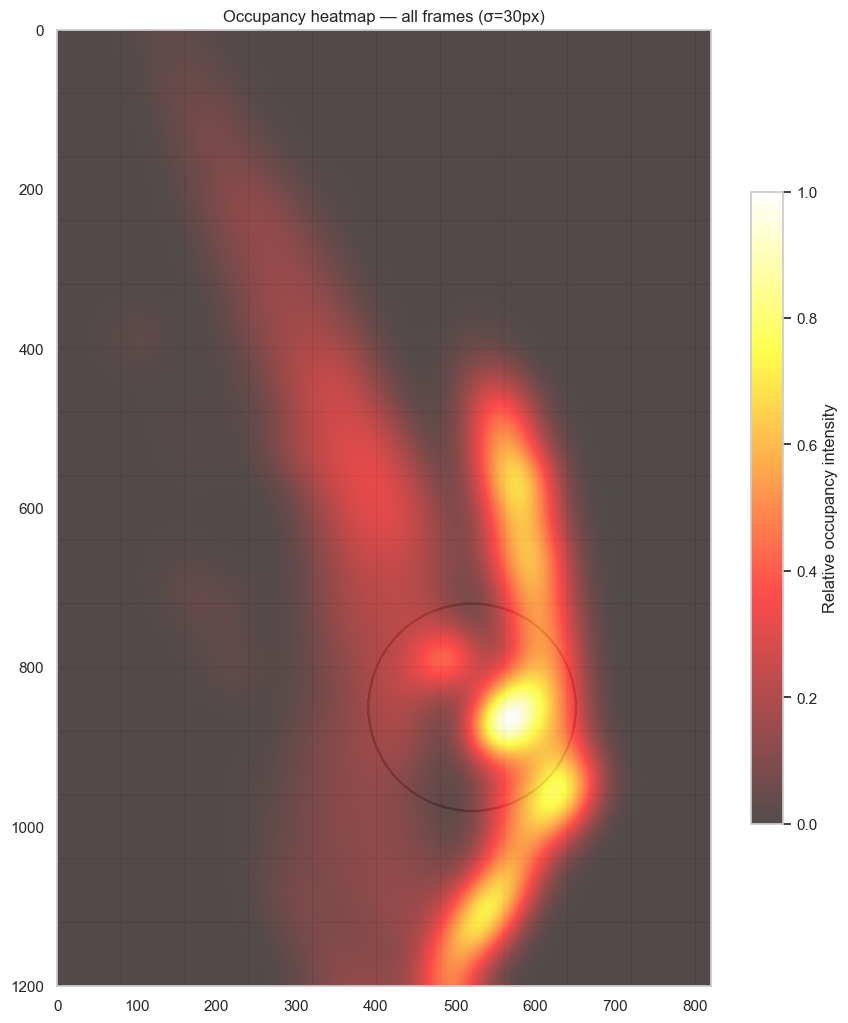

In [5]:
def make_floor_canvas():
    fp = np.ones((FLOOR_H, FLOOR_W, 3), dtype=np.uint8) * 245
    for x in range(0, FLOOR_W, 80):
        cv2.line(fp, (x, 0), (x, FLOOR_H), (215, 215, 215), 1)
    for y in range(0, FLOOR_H, 80):
        cv2.line(fp, (0, y), (FLOOR_W, y), (215, 215, 215), 1)
    cv2.ellipse(fp, (cx, cy), (R, R), 0, 0, 360, (170, 170, 170), 2)
    return fp

fig, ax = plt.subplots(figsize=(9, 13))
ax.imshow(make_floor_canvas(), extent=[0, FLOOR_W, FLOOR_H, 0])
im = ax.imshow(heatmap_norm, extent=[0, FLOOR_W, FLOOR_H, 0],
               cmap='hot', alpha=0.7, vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Relative occupancy intensity', shrink=0.5)
ax.grid(False)
ax.set_title(f'Occupancy heatmap — all frames (σ={sigma}px)', fontsize=12)
plt.tight_layout()
plt.show()

## Experiment with colourmap and smoothing

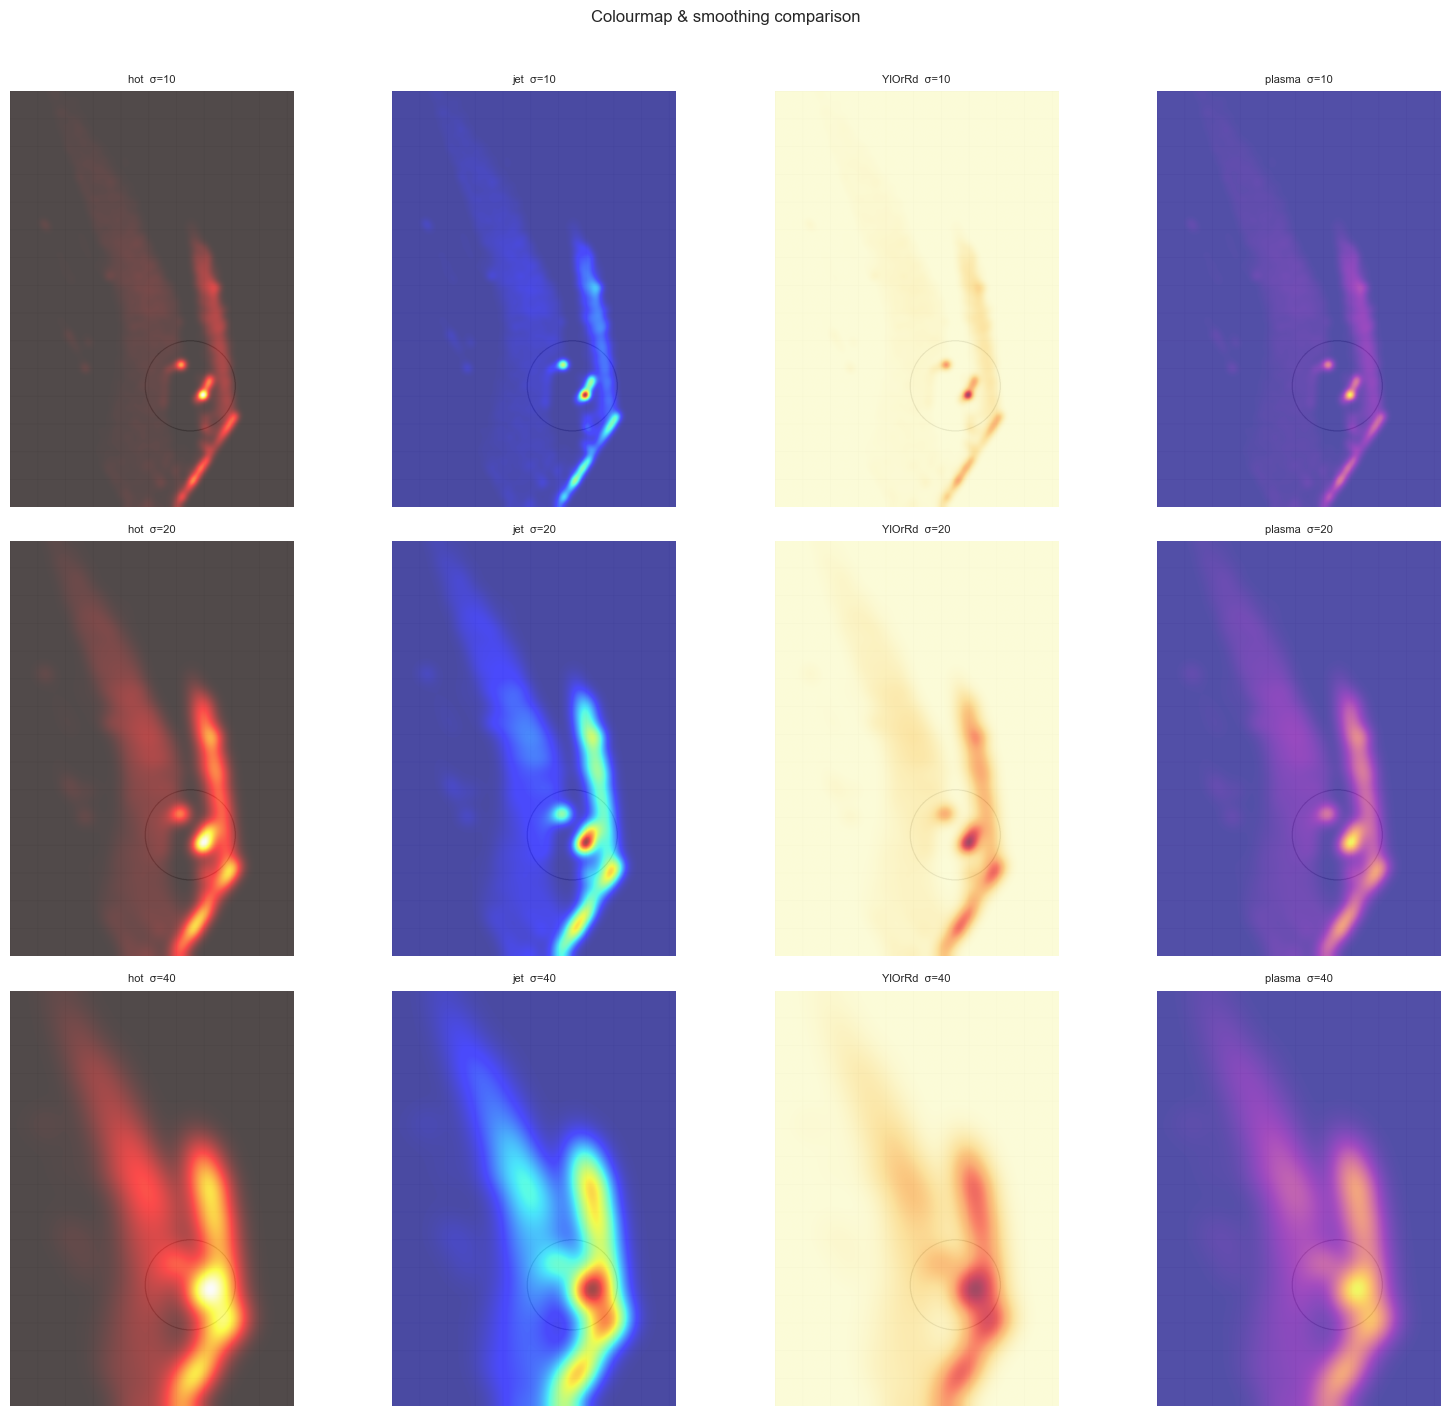

In [6]:
cmaps = ['hot', 'jet', 'YlOrRd', 'plasma']
sigmas = [10, 20, 40]

fig, axes = plt.subplots(len(sigmas), len(cmaps), figsize=(16, 14))

for row, s in enumerate(sigmas):
    sm = gaussian_filter(heatmap, sigma=s)
    for col, cmap in enumerate(cmaps):
        ax = axes[row, col]
        ax.imshow(make_floor_canvas(), extent=[0, FLOOR_W, FLOOR_H, 0])
        ax.imshow(sm, extent=[0, FLOOR_W, FLOOR_H, 0], cmap=cmap, alpha=0.7, vmin=0)
        ax.grid(False)
        ax.set_title(f'{cmap}  σ={s}', fontsize=8)
        ax.axis('off')

plt.suptitle('Colourmap & smoothing comparison', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()